In [11]:
import sys
import os

import numpy as np
import xarray as xr
import pandas as pd
from scipy import stats

try:
    """
    Si la libreria esta instalada
    """
    import mhw.datasets_utils as dsu # control de dataset facilitando el uso, no obligatorio
    import mhw.mhw_core as mhw # core del script 
    import mhw.time_utils as timeu # herramientas y utilidades del manejo del tiempo
    
except ImportError:
    """
    Si la libreria no se instalado o no desea ser instalada. Importante,
    esto es posible si y solo si la notebook esta ubicada en ./mwh/notebooks/
    """
    # Ruta ubicacion scripts mhw
    ruta_mhw = os.path.abspath(os.path.join('..', 'mhw'))

    # Agregamos la ruta al sistema
    if ruta_mhw not in sys.path:
        sys.path.append(ruta_mhw)
    
    import datasets_utils as dsu
    import mhw_core as mhw
    import time_utils as timeu
    from stats_and_trends import trend_matrix


import matplotlib.pyplot as plt
import matplotlib.axes as maxes
# Cartopy 
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.crs import PlateCarree
from cartopy.feature import LAND, COASTLINE, RIVERS
# Beatiful ocean
from cmocean.cm import haline, thermal

import warnings
# Ignora warnings especificamente de numpy y la existencia de arrays con nans
warnings.filterwarnings("ignore", message="All-NaN slice encountered")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
is_significative = np.where(pvalue.values < .1, 1, np.nan)

# Analisis y Graficos de ejemplo

Para utilizar esta notebook es necesario haber entendido bien la primera notebook. En esta vamos
a encontrar como hacer distintos graficos/analisis a partir de los datasets generados en el Tutorial I. 

Vamos a necestar los archivos: 

- pcaso_anual_stats.nc
- pcaso_seasonal_stats.nc
- pcaso_monthly_stats.nc
- pcaso_waves.nc

### Ejemplo I: Grafico de eventos totales, duracion media, maxima intensidad e intensidad media

In [36]:
# cargamos dataset anual
ds_anual = xr.open_dataset(dsu.join_path(dsu.DIR_DATASETS, "pcaso_anual_stats.nc"))

In [40]:
# sumamos sobre "axis tiemepo", obteniendo una grilla de eventos 
eventos_totales = ds_anual.total_events.sum(axis=0, skipna=True)
# calculamos el maximo de anomalia observada por pixel
anomalias_maximas = ds_anual.anom_max.max(axis=0, skipna=True)
# calculamos el premedio de las anomalias maximas observadas (anio a anio)
anomalias_maximas = ds_anual.anom_max.mean(axis=0, skipna=True)
# calculamos la duracion media de los eventos (anio a anio)
duration_mean = ds_anual.duration.mean(axis=0, skipna=True)
# *importante en M.L. Clara et al la estimacion de algunas de estas metricas fue levemente diferente

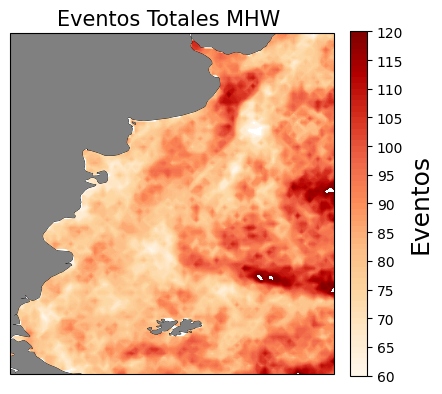

In [31]:
shrink = .43
pad = 0.04
color = "k"
levels = np.arange(60, 120.01, 1)
ticks = range(60, 125, 5)


fig = plt.figure(figsize=(4, 8))
ax0 = fig.add_axes([0, 0., 1, 1], projection=PlateCarree()) 

ax0.set_facecolor('white')
ax0.add_feature(LAND, facecolor="gray", zorder=2)
ax0.add_feature(COASTLINE, linewidth=0.5)
ax0.set_title("Eventos Totales MHW ", size=15)


im = ax0.contourf(ds_anual.lon - 360, ds_anual.lat, eventos_totales,levels=levels, cmap="OrRd",  zorder=0)
clb = plt.colorbar(
    im, 
    ticks=ticks, 
    shrink=shrink, 
    pad=pad, 
    extend='both', 
    drawedges=False, 
    orientation="vertical")
clb.set_label("Eventos", size=18)
clb.ax.tick_params(rotation=0)
plt.show()

### Ejemplo II: Tendencia de eventos anuales y estacionales

In [ ]:
trend, pvalue, intercept = trend_matrix(ds_anual.total_events, time_dim="year")

### Ejemplo III: Heatmap % de area cubierta por olas de calor

### Ejemplo IV: MovieMaker - Visualizando las olas de calor